# Text Mining the Epstein Files (DOJ Dataset 12)

This notebook implements a systematic pipeline for extracting an interaction network ('Who met whom, when, and where') from unstructured, noisy documents. 

**Pipeline Overview:**
1. **Setup & Ingestion:** Extract text from PDFs and clean OCR/redaction artifacts.
2. **EDA:** Understand the linguistic structure of the dataset.
3. **NER Pipeline:** Extract People, Organizations, and Locations using `spaCy`.
4. **Relation Extraction (RE):** Identify interactions using dependency parsing (Heuristic approach) and prepare for LLM extraction.
5. **Knowledge Graph Construction:** Visualize the findings using `NetworkX`.

## Phase 1: Environment Setup
Install the required libraries for NLP, PDF processing, and network visualization.

In [7]:
%pip install -q PyMuPDF spacy networkx matplotlib seaborn pandas transformers accelerate bitsandbytes
!python -m spacy download en_core_web_sm
print('Dependencies installed successfully!')

Note: you may need to restart the kernel to use updated packages.

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --------------------------------------- 0.0/12.8 MB 165.2 kB/s eta 0:01:18
     --------------------------------------- 0.0/12.8 MB 245.8 kB/s eta 0:00:52
     --------------------------------------- 0.1/12.8 MB 357.2 kB/s eta 0:00:36
     -- ------------------------------------- 0.8/12.8 MB 3.8 MB/s eta 0:00:04
     ------- -------------------------------- 2.3/12.8 MB 9.8 MB/s eta 0:00:02
     ------------- -------------------------- 4.4/12.8 MB 15.5 MB/s eta 0:00:01
     ---------------------- ----------------- 7.2/12.8 MB 23.2 MB/s eta 0:00:01
     ------------------------------ -------- 10.0/12.8 MB 29.1 MB/s eta 0:00:01
     --------------------------------------  12.8/12.8 MB 73.1 MB/s eta 0:00:01

## Phase 2: Data Loading & Preprocessing
DOJ Data Set 12 PDFs are already available in `data/raw_pdfs` prepared by `crawl.py`. This phase loads valid PDFs and cleans common OCR/redaction artifacts before NLP processing.

In [72]:
import fitz  # PyMuPDF
import os
import re
from collections import Counter
from pathlib import Path

RAW_PDF_DIR = "data/raw_pdfs"
MAX_FILES_TO_LOAD = None  # Set to None to use all PDFs in RAW_PDF_DIR

NOISE_LINE_MARKERS = [
    "skip to main content",
    "menu search",
    "epstein library",
    "privacy notice",
    "are you 18 years of age or older",
    "return to the top of the page",
    "contact the department",
    "signup for email updates",
    "links to other government and non-government sites",
    "u.s. department of justice",
    "950 pennsylvania avenue",
]

def is_valid_pdf_file(filepath):
    try:
        with open(filepath, "rb") as f:
            return f.read(5) == b"%PDF-"
    except OSError:
        return False

def load_pdf_text(filepath):
    """Extracts raw text from one PDF file."""
    if not os.path.exists(filepath) or not is_valid_pdf_file(filepath):
        return None
    with fitz.open(filepath) as doc:
        return "\n".join(page.get_text("text") for page in doc)

def strip_pdf_boilerplate(text, repeated_line_threshold=30):
    """Removes recurring headers/footers and navigation boilerplate from extracted PDF text."""
    lines = [re.sub(r"\s+", " ", line).strip() for line in text.splitlines()]
    non_empty = [line for line in lines if line]
    line_counts = Counter(non_empty)

    cleaned_lines = []
    for line in lines:
        if not line:
            continue
        lower = line.lower()

        if line_counts[line] >= repeated_line_threshold:
            continue
        if any(marker in lower for marker in NOISE_LINE_MARKERS):
            continue
        if re.fullmatch(r"page\s*\d+(\s*of\s*\d+)?", lower):
            continue
        if re.fullmatch(r"\d{1,4}", line):
            continue
        if len(line) <= 1:
            continue

        cleaned_lines.append(line)

    return "\n".join(cleaned_lines)

def clean_text(text):
    """Standardizes whitespace and handles redaction markers systematically."""
    text = text.replace("[REDACTED]", "REDACTED_ENTITY")
    text = strip_pdf_boilerplate(text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def load_all_pdf_texts(folder_path, max_files=None):
    """Loads valid PDFs, cleans each file independently, and returns combined corpora plus per-file records."""
    pdf_paths = sorted(Path(folder_path).glob("*.pdf"))
    if max_files is not None:
        pdf_paths = pdf_paths[:max_files]

    file_records = []
    invalid_pdf_count = 0

    for pdf_path in pdf_paths:
        text = load_pdf_text(str(pdf_path))
        if text is None:
            invalid_pdf_count += 1
            continue

        cleaned = clean_text(text)
        if not cleaned:
            continue

        file_records.append(
            {
                "path": str(pdf_path),
                "raw_text": text,
                "cleaned_text": cleaned,
            }
        )

    raw_concat = "\n".join(record["raw_text"] for record in file_records)
    cleaned_concat = " ".join(record["cleaned_text"] for record in file_records)
    return raw_concat, cleaned_concat, file_records, invalid_pdf_count

raw_text, cleaned_text, pdf_records, invalid_pdf_count = load_all_pdf_texts(
    RAW_PDF_DIR,
    max_files=MAX_FILES_TO_LOAD,
)
used_files = [record["path"] for record in pdf_records]

if not used_files:
    raise FileNotFoundError(
        f"No valid PDFs were found in {RAW_PDF_DIR}. Run crawl.py first to populate this folder."
    )

print(f"Loaded text from {len(used_files)} valid PDF files.")
print(f"Skipped {invalid_pdf_count} invalid/non-PDF files.")

raw_length = len(raw_text)
print(f"Raw text length: {raw_length} characters")
print(f"Cleaned text length: {len(cleaned_text)} characters")
print(f"Average cleaned characters per valid file: {int(len(cleaned_text) / max(len(used_files), 1))}")

Loaded text from 175 valid PDF files.
Skipped 0 invalid/non-PDF files.
Raw text length: 3398694 characters
Cleaned text length: 3028697 characters
Average cleaned characters per valid file: 17306


## Phase 3: Exploratory Data Analysis (EDA)
Understanding sentence length distributions helps us tune our Relation Extraction window.

Processed 175 files individually and produced 181 spaCy chunks for downstream extraction.
Sentence filtering kept 22689 of 27180 sentences (83.5%).
Top files by kept sentence count:
  EFTA02857863.pdf: 4783
  EFTA02857524.pdf: 2816
  EFTA02730274.pdf: 1627
  EFTA02731082.pdf: 1531
  EFTA02857763.pdf: 1226


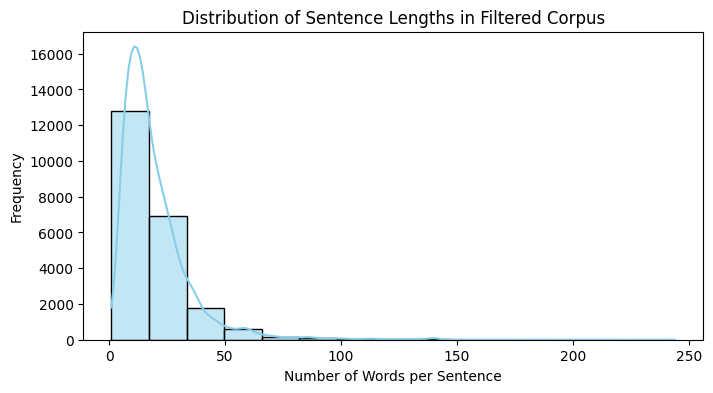

In [73]:
import re
from pathlib import Path
import spacy
import matplotlib.pyplot as plt
import seaborn as sns

nlp = spacy.load('en_core_web_sm')

NOISE_SENTENCE_MARKERS = [
    'links to other government and non-government sites',
    'return to the top of the page',
    'contact usa.gov',
    'privacy notice',
    'epstein library',
    'menu search',
]

def is_informative_sentence(sentence_text):
    text = sentence_text.strip()
    if not text:
        return False

    lowered = text.lower()
    if any(marker in lowered for marker in NOISE_SENTENCE_MARKERS):
        return False

    words = re.findall(r"[A-Za-z][A-Za-z'-]*", text)
    if len(words) < 4 or len(words) > 140:
        return False

    alpha_ratio = sum(ch.isalpha() for ch in text) / max(len(text), 1)
    if alpha_ratio < 0.35:
        return False

    if re.fullmatch(r"(page\s*\d+(\s*of\s*\d+)?)|\d+", lowered):
        return False

    return True

def chunk_text(text, max_chars=180000):
    """Chunks text at sentence-like boundaries to keep spaCy processing memory-safe."""
    segments = re.split(r"(?<=[\n.!?])\s+", text)
    chunks = []
    current = []
    current_len = 0

    for segment in segments:
        piece = segment.strip()
        if not piece:
            continue
        piece_len = len(piece) + 1

        if current and current_len + piece_len > max_chars:
            chunks.append(' '.join(current))
            current = [piece]
            current_len = piece_len
        else:
            current.append(piece)
            current_len += piece_len

    if current:
        chunks.append(' '.join(current))

    return chunks

def build_docs_for_text(text, max_chars=180000):
    if not text:
        return [], 0, 0

    raw_chunks = chunk_text(text, max_chars=max_chars)
    if not raw_chunks:
        return [], 0, 0

    raw_sentences = []
    for doc_chunk in nlp.pipe(raw_chunks, batch_size=1):
        raw_sentences.extend(sent.text.strip() for sent in doc_chunk.sents)

    filtered_sentences = [sent for sent in raw_sentences if is_informative_sentence(sent)]

    if filtered_sentences:
        filtered_text = ' '.join(filtered_sentences)
        filtered_chunks = chunk_text(filtered_text, max_chars=max_chars)
        docs_local = list(nlp.pipe(filtered_chunks, batch_size=1))
    else:
        docs_local = list(nlp.pipe(raw_chunks, batch_size=1))

    return docs_local, len(raw_sentences), len(filtered_sentences)

docs_by_file = []
total_raw_sentences = 0
total_filtered_sentences = 0

if 'pdf_records' in globals() and pdf_records:
    for record in pdf_records:
        docs_local, raw_count, filtered_count = build_docs_for_text(record['cleaned_text'], max_chars=180000)
        total_raw_sentences += raw_count
        total_filtered_sentences += filtered_count

        if docs_local:
            docs_by_file.append(
                {
                    'path': record['path'],
                    'docs': docs_local,
                    'raw_sentence_count': raw_count,
                    'filtered_sentence_count': filtered_count,
                }
            )
else:
    docs_local, raw_count, filtered_count = build_docs_for_text(cleaned_text, max_chars=180000)
    total_raw_sentences += raw_count
    total_filtered_sentences += filtered_count
    docs_by_file = [
        {
            'path': '<combined_text>',
            'docs': docs_local,
            'raw_sentence_count': raw_count,
            'filtered_sentence_count': filtered_count,
        }
    ]

docs = [doc_chunk for entry in docs_by_file for doc_chunk in entry['docs']]
doc = docs[0] if docs else nlp('')

print(
    f"Processed {len(docs_by_file)} files individually "
    f"and produced {len(docs)} spaCy chunks for downstream extraction."
)
if total_raw_sentences > 0:
    keep_ratio = total_filtered_sentences / total_raw_sentences
    print(
        f"Sentence filtering kept {total_filtered_sentences} of {total_raw_sentences} sentences "
        f"({keep_ratio:.1%})."
    )

if docs_by_file:
    top_files = sorted(
        (
            (Path(entry['path']).name, entry['filtered_sentence_count'])
            for entry in docs_by_file
        ),
        key=lambda x: x[1],
        reverse=True,
    )[:5]
    print('Top files by kept sentence count:')
    for name, count in top_files:
        print(f"  {name}: {count}")

sentence_lengths = [len(sent.text.split()) for d in docs for sent in d.sents]

plt.figure(figsize=(8, 4))
sns.histplot(sentence_lengths, bins=15, kde=True, color='skyblue')
plt.title('Distribution of Sentence Lengths in Filtered Corpus')
plt.xlabel('Number of Words per Sentence')
plt.ylabel('Frequency')
plt.show()

## Phase 4: Named Entity Recognition (NER)
Extracting specific entities (People, Locations, Dates) to form the nodes of our graph.

In [74]:
import re
import pandas as pd

PERSON_TITLE_RE = re.compile(r"^(mr|mrs|ms|dr|sir)\.?\s+", flags=re.IGNORECASE)
NOISE_ENTITY_TERMS = {
    "justice.gov",
    "u.s. department of justice",
    "epstein library",
    "contact usa.gov",
    "contact the department",
    "privacy notice",
    "menu search",
    "return to the top of the page",
}

def normalize_entity_text(text, label):
    normalized = re.sub(r"\s+", " ", text).strip(" ,.;:()[]{}\"'")
    normalized = PERSON_TITLE_RE.sub("", normalized)

    if label == "GPE" and normalized.lower().startswith("the "):
        normalized = normalized[4:]

    if label == "PERSON":
        if re.fullmatch(r"epstein", normalized, flags=re.IGNORECASE):
            return "Jeffrey Epstein"
        if re.search(r"jeffrey\s+epstein", normalized, flags=re.IGNORECASE):
            return "Jeffrey Epstein"

    return normalized

def is_entity_noise(entity_text, label):
    lowered = entity_text.lower()

    if not entity_text or len(entity_text) < 2:
        return True
    if lowered in NOISE_ENTITY_TERMS:
        return True
    if re.fullmatch(r"\d{1,4}", entity_text):
        return True

    if label in {"ORG", "GPE"} and any(
        marker in lowered for marker in ["justice.gov", "contact", "privacy notice", "epstein library"]
    ):
        return True

    return False

working_docs = docs if 'docs' in globals() and docs else [doc]

entities = []
for doc_chunk in working_docs:
    for ent in doc_chunk.ents:
        if ent.label_ in ["PERSON", "ORG", "GPE", "DATE"]:
            normalized = normalize_entity_text(ent.text, ent.label_)
            if is_entity_noise(normalized, ent.label_):
                continue
            entities.append({
                "EntityRaw": ent.text,
                "Entity": normalized,
                "Label": ent.label_,
            })

df_ents = pd.DataFrame(entities, columns=["EntityRaw", "Entity", "Label"])
if df_ents.empty:
    print("No entities extracted after filtering.")
else:
    df_ents["Mentions"] = df_ents.groupby(["Entity", "Label"])["Entity"].transform("size")
    df_ents = (
        df_ents.sort_values(["Mentions", "Label", "Entity"], ascending=[False, True, True])
        .drop_duplicates(subset=["Entity", "Label"])
        .reset_index(drop=True)
    )
    print("Top normalized entities:")
    print(df_ents.head(15))

Top normalized entities:
            EntityRaw             Entity   Label  Mentions
0     Jeffrey Epstein    Jeffrey Epstein  PERSON      1462
1              BOX MM             BOX MM     ORG       659
2             Maxwell            Maxwell     ORG       654
3                Jane               Jane  PERSON       628
4             Florida            Florida     GPE       586
5            New York           New York     GPE       581
6                 FBI                FBI     ORG       433
7   the United States      United States     GPE       431
8          Palm Beach         Palm Beach     GPE       336
9            \ prod \           \ prod \  PERSON       336
10             \ prod             \ prod  PERSON       291
11              \ DCU              \ DCU     ORG       290
12          Defendant          Defendant  PERSON       232
13            1234023            1234023    DATE       225
14  Palm Beach County  Palm Beach County     GPE       180


## Phase 5: Relation Extraction (RE)
**Method A (Hybrid Rule-Based, Person-to-Person):** We use dependency roles (subject/object/preposition-object) with an interaction-verb lexicon and only keep relationships where both entities are recognized as persons.

In [83]:
import re
from collections import defaultdict
from pathlib import Path

interaction_verb_map = {
    'meet': 'met',
    'encounter': 'met',
    'visit': 'visited',
    'travel': 'traveled',
    'fly': 'flew',
    'email': 'emailed',
    'contact': 'contacted',
    'communicate': 'contacted',
    'call': 'called',
    'phone': 'called',
    'speak': 'spoke',
    'talk': 'spoke',
    'interview': 'spoke',
    'discuss': 'discussed',
    'invite': 'invited',
    'introduce': 'invited',
    'arrange': 'arranged',
    'schedule': 'arranged',
    'book': 'arranged',
    'accompany': 'accompanied',
    'escort': 'accompanied',
}
subject_deps = {'nsubj', 'nsubjpass', 'csubj'}
object_deps = {'dobj', 'obj', 'iobj', 'pobj', 'dative', 'attr', 'oprd'}

# Balanced recall + precision controls
MAX_RELAXED_DISTANCE = 12
MAX_FALLBACK_DISTANCE = 10
MAX_FALLBACK_ENTITY_GAP = 22
MAX_FALLBACK_PERSONS_IN_SENTENCE = 8
MIN_FALLBACK_NAME_TOKENS = 1
ALLOW_RELAXED_DEPENDENCY = True
ALLOW_PROXIMITY_FALLBACK = True
FALLBACK_REQUIRE_PERSON_PERSON = True
RELATION_ENTITY_LABEL = 'PERSON'
PERSON_LIKE_ENTITY_LABELS = {'PERSON', 'ORG'}
ALLOW_ORG_PERSON_ALIASES = True
FALLBACK_ALLOWED_INTERACTIONS = set(interaction_verb_map.values())

# Cross-sentence pronoun controls
PRONOUN_GENDER_MAP = {
    'he': 'male',
    'him': 'male',
    'she': 'female',
    'her': 'female',
}
COREF_MEMORY_SENTENCE_WINDOW = 4
COREF_MAX_RECENT_MENTIONS = 24

PERSON_EXCLUSION_TERMS = {
    'intl',
    'international',
    'airport',
    'avenue',
    'street',
    'road',
    'boulevard',
    'blvd',
    'highway',
    'beach',
    'island',
    'residence',
    'city',
    'county',
    'state',
    'province',
    'country',
    'terminal',
    'station',
    'serial',
    'title',
    'transport',
    'documents',
    'office',
    'record',
    'records',
    'scans',
    'eastern',
    'time',
    'birth',
    'redacted',
    'anonymous',
    'male',
    'female',
    'caller',
}

NON_PERSON_CONTEXT_TERMS = {
    'account',
    'number',
    'social',
    'security',
    'synopsis',
    'transcript',
    'continuation',
    'reviewed',
    'analyst',
    'analysis',
    'intelligence',
    'district',
    'department',
    'agency',
    'agencies',
    'agents',
    'agent',
    'division',
    'divisions',
    'report',
    'file',
    'memo',
    'subject',
    'wsta',
    'prostitution',
    'victim',
    'witness',
    'call',
    'club',
    'inc',
    'llc',
    'corp',
    'corporation',
    'center',
    'medicine',
}

ALLOWED_PARTICLE_TOKENS = {
    'de',
    'da',
    'del',
    'van',
    'von',
    'la',
    'le',
    'st',
    'saint',
    'bin',
    'al',
    'el',
    'di',
}

FALLBACK_CONNECTOR_RE = re.compile(r'\b(with|and|to|between|alongside)\b', flags=re.IGNORECASE)

def normalize_person_name(name):
    cleaned = re.sub(r"\b([A-Za-z]+)'s\b", r'\1', name)
    cleaned = re.sub(r"[^A-Za-z\-\s']", ' ', cleaned)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip(" -'")
    return cleaned

def person_tokens(name):
    return re.findall(r"[A-Za-z]+(?:-[A-Za-z]+)?", name)

def has_non_person_context(name):
    lowered = name.lower()
    return any(term in lowered for term in NON_PERSON_CONTEXT_TERMS)

def looks_like_person_entity(name):
    if not name:
        return False
    if any(ch.isdigit() for ch in name):
        return False

    tokens = person_tokens(name)
    if not tokens or len(tokens) > 5:
        return False
    if any(len(token) <= 1 for token in tokens):
        return False

    if has_non_person_context(name):
        return False

    for token in tokens:
        lowered = token.lower()
        if lowered in ALLOWED_PARTICLE_TOKENS:
            continue
        if lowered in PERSON_EXCLUSION_TERMS:
            return False
        if token.isupper() and len(token) > 2:
            return False
        if not token[0].isupper():
            return False

    if len(tokens) == 1:
        token = tokens[0]
        if len(token) < 4 or token.isupper():
            return False

    return True

def is_org_alias_candidate(name):
    tokens = person_tokens(name)
    if len(tokens) < 2 or len(tokens) > 3:
        return False
    if has_non_person_context(name):
        return False
    if any(token.isupper() and len(token) > 2 for token in tokens):
        return False
    return looks_like_person_entity(name)

def name_token_count(name):
    return len(person_tokens(name))

def fallback_name_ok(name):
    return name_token_count(name) >= MIN_FALLBACK_NAME_TOKENS

def has_fallback_connector(doc_obj, first_token_i, second_token_i):
    left = min(first_token_i, second_token_i)
    right = max(first_token_i, second_token_i)
    between_text = doc_obj[left:right + 1].text
    return bool(FALLBACK_CONNECTOR_RE.search(between_text))

def dedupe_entity_records(records):
    seen = set()
    deduped = []
    for record in records:
        key = (record['norm'], record['label'])
        if key not in seen:
            seen.add(key)
            deduped.append(record)
    return deduped

def token_is_linked_to_verb(token, verb, max_hops=3):
    node = token
    for _ in range(max_hops):
        if node == verb:
            return True
        if node == node.head:
            break
        node = node.head
    return node == verb

def collect_entities_from_tokens(tokens, entity_records):
    collected = []
    for token in tokens:
        for record in entity_records:
            if record['span'].start <= token.i < record['span'].end:
                collected.append(record)
    return dedupe_entity_records(collected)

def build_surname_alias_map():
    surname_to_full = defaultdict(set)
    if 'df_ents' in globals() and not df_ents.empty:
        person_rows = df_ents[df_ents['Label'] == 'PERSON']
        for raw_name in person_rows['Entity'].dropna().unique().tolist():
            if not isinstance(raw_name, str):
                continue
            normalized = normalize_person_name(raw_name)
            if not looks_like_person_entity(normalized):
                continue
            tokens = normalized.split()
            if len(tokens) >= 2:
                surname_to_full[tokens[-1].lower()].add(normalized)
    return {k: next(iter(v)) for k, v in surname_to_full.items() if len(v) == 1}

def canonicalize_person_name(name, surname_alias_map):
    tokens = name.split()
    if len(tokens) == 1:
        surname = tokens[0].lower()
        if surname in surname_alias_map:
            return surname_alias_map[surname]
    return name

def build_trusted_person_names(surname_alias_map, min_mentions_single=1):
    trusted = set()

    if 'df_ents' in globals() and not df_ents.empty:
        person_rows = df_ents[df_ents['Label'] == 'PERSON']
        for _, row in person_rows.iterrows():
            raw_name = str(row.get('Entity', '')).strip()
            norm = normalize_person_name(raw_name)
            norm = canonicalize_person_name(norm, surname_alias_map)
            if not looks_like_person_entity(norm):
                continue

            mentions = 1
            try:
                mentions = int(row.get('Mentions', 1))
            except Exception:
                mentions = 1

            if name_token_count(norm) >= 2 or mentions >= min_mentions_single:
                trusted.add(norm)

    if 'df_rel' in globals() and not df_rel.empty:
        for col in ['Entity1', 'Entity2']:
            for raw_name in df_rel[col].dropna().tolist():
                norm = normalize_person_name(str(raw_name))
                norm = canonicalize_person_name(norm, surname_alias_map)
                if looks_like_person_entity(norm):
                    trusted.add(norm)

    return trusted

def is_name_allowed(name, trusted_person_names):
    return name_token_count(name) >= 2 or name in trusted_person_names

def score_pair(first, second, verb, sent):
    token_gap = abs(first['root'].i - second['root'].i)
    opposite_sides = (first['root'].i - verb.i) * (second['root'].i - verb.i) <= 0
    has_connector = has_fallback_connector(sent.doc, first['root'].i, second['root'].i)
    first_linked = token_is_linked_to_verb(first['root'], verb, max_hops=2)
    second_linked = token_is_linked_to_verb(second['root'], verb, max_hops=2)

    score = 0.0
    score += 1.5 if opposite_sides else 0.0
    score += 1.25 if has_connector else 0.0
    score += 1.25 if first_linked else 0.0
    score += 1.25 if second_linked else 0.0
    score += 0.5 if fallback_name_ok(first['norm']) else 0.0
    score += 0.5 if fallback_name_ok(second['norm']) else 0.0
    score -= min(token_gap, 20) * 0.06

    return score, has_connector, first_linked, second_linked

def select_best_pair(candidates, verb, sent, min_score=1.9, require_any_link=True):
    best_pair = None
    best_score = float('-inf')

    for i in range(len(candidates)):
        for j in range(i + 1, len(candidates)):
            first = candidates[i]
            second = candidates[j]

            if first['norm'] == second['norm']:
                continue
            if FALLBACK_REQUIRE_PERSON_PERSON and not (
                first['label'] == RELATION_ENTITY_LABEL and second['label'] == RELATION_ENTITY_LABEL
            ):
                continue
            if not looks_like_person_entity(first['norm']) or not looks_like_person_entity(second['norm']):
                continue
            if abs(first['root'].i - second['root'].i) > MAX_FALLBACK_ENTITY_GAP:
                continue

            score, has_connector, first_linked, second_linked = score_pair(first, second, verb, sent)
            if require_any_link and not (first_linked or second_linked):
                continue
            if score >= min_score and score > best_score:
                best_score = score
                best_pair = (first, second)

    return best_pair

def prune_recent_context(recent_context, current_sent_idx):
    kept = [
        rec for rec in recent_context
        if (current_sent_idx - rec['sent_idx']) <= COREF_MEMORY_SENTENCE_WINDOW
    ]
    return kept[-COREF_MAX_RECENT_MENTIONS:]

def resolve_pronouns_in_sentence(sent, explicit_records, recent_context, coref_state, surname_alias_map, trusted_person_names):
    resolved = []

    for tok in sent:
        pron = tok.text.lower()
        if pron not in PRONOUN_GENDER_MAP:
            continue

        gender = PRONOUN_GENDER_MAP[pron]
        antecedent = None

        same_sentence_prior = [rec for rec in explicit_records if rec['root'].i < tok.i]
        if same_sentence_prior:
            unique_names = sorted({rec['norm'] for rec in same_sentence_prior})
            subject_like = [rec for rec in same_sentence_prior if rec['root'].dep_ in subject_deps]
            subject_names = sorted({rec['norm'] for rec in subject_like})

            if len(unique_names) == 1:
                antecedent = unique_names[0]
            elif len(subject_names) == 1:
                antecedent = subject_names[0]
            elif coref_state.get(gender) in unique_names:
                antecedent = coref_state[gender]

        if antecedent is None and coref_state.get(gender):
            antecedent = coref_state[gender]

        if antecedent is None:
            recent_names = []
            for ctx in reversed(recent_context):
                if ctx['norm'] not in recent_names:
                    recent_names.append(ctx['norm'])
            if len(recent_names) == 1:
                antecedent = recent_names[0]

        if antecedent is None:
            continue

        antecedent = canonicalize_person_name(antecedent, surname_alias_map)
        if not looks_like_person_entity(antecedent):
            continue
        if not is_name_allowed(antecedent, trusted_person_names):
            continue

        resolved.append({
            'span': tok.doc[tok.i:tok.i + 1],
            'norm': antecedent,
            'label': RELATION_ENTITY_LABEL,
            'root': tok,
            'is_pronoun_proxy': True,
            'pronoun': pron,
        })
        coref_state[gender] = antecedent
        coref_state['last'] = antecedent

    return dedupe_entity_records(resolved)

surname_alias_map = build_surname_alias_map()
trusted_person_names = build_trusted_person_names(surname_alias_map=surname_alias_map)
relations = []
pronoun_resolution_hits = 0

if 'docs_by_file' in globals() and docs_by_file:
    doc_groups = docs_by_file
else:
    fallback_docs = docs if 'docs' in globals() and docs else [doc]
    doc_groups = [{'path': '<combined_text>', 'docs': fallback_docs}]

for group in doc_groups:
    source_file = group.get('path', '')
    docs_in_group = group.get('docs', [])

    for doc_chunk in docs_in_group:
        recent_person_context = []
        coref_state = {'male': None, 'female': None, 'last': None}

        for sent_idx, sent in enumerate(doc_chunk.sents):
            recent_person_context = prune_recent_context(recent_person_context, sent_idx)

            raw_entities = [ent for ent in sent.ents if ent.label_ in PERSON_LIKE_ENTITY_LABELS]
            explicit_records = []
            for ent in raw_entities:
                norm = normalize_entity_text(ent.text, ent.label_)
                norm = normalize_person_name(norm)
                if is_entity_noise(norm, ent.label_):
                    continue

                if ent.label_ == 'ORG':
                    if not ALLOW_ORG_PERSON_ALIASES:
                        continue
                    if not is_org_alias_candidate(norm):
                        continue
                else:
                    if not looks_like_person_entity(norm):
                        continue

                norm = canonicalize_person_name(norm, surname_alias_map)
                if not looks_like_person_entity(norm):
                    continue
                if not is_name_allowed(norm, trusted_person_names):
                    continue
                explicit_records.append({
                    'span': ent,
                    'norm': norm,
                    'label': RELATION_ENTITY_LABEL,
                    'root': ent.root,
                    'is_pronoun_proxy': False,
                })
            explicit_records = dedupe_entity_records(explicit_records)

            verb_tokens = [
                token for token in sent
                if token.pos_ == 'VERB' and token.lemma_.lower() in interaction_verb_map
            ]
            if not verb_tokens:
                recent_person_context.extend(
                    {'norm': rec['norm'], 'sent_idx': sent_idx, 'root_i': rec['root'].i}
                    for rec in explicit_records
                )
                recent_person_context = recent_person_context[-COREF_MAX_RECENT_MENTIONS:]
                continue

            pronoun_records = resolve_pronouns_in_sentence(
                sent,
                explicit_records,
                recent_person_context,
                coref_state,
                surname_alias_map,
                trusted_person_names,
            )
            pronoun_resolution_hits += len(pronoun_records)

            entity_records = dedupe_entity_records(explicit_records + pronoun_records)

            if len(entity_records) < 2:
                recent_person_context.extend(
                    {'norm': rec['norm'], 'sent_idx': sent_idx, 'root_i': rec['root'].i}
                    for rec in explicit_records
                )
                recent_person_context = recent_person_context[-COREF_MAX_RECENT_MENTIONS:]
                continue

            dates = [
                normalize_entity_text(ent.text, ent.label_)
                for ent in sent.ents
                if ent.label_ == 'DATE'
            ]
            locations = []
            for ent in sent.ents:
                if ent.label_ == 'GPE':
                    location = normalize_entity_text(ent.text, ent.label_)
                    if not is_entity_noise(location, ent.label_):
                        locations.append(location)

            for verb in verb_tokens:
                interaction = interaction_verb_map[verb.lemma_.lower()]

                subject_tokens = []
                object_tokens = []

                for child in verb.children:
                    if child.dep_ in subject_deps:
                        subject_tokens.append(child)
                        subject_tokens.extend(list(child.conjuncts))
                    elif child.dep_ in object_deps:
                        object_tokens.append(child)
                        object_tokens.extend(list(child.conjuncts))
                    elif child.dep_ in {'prep', 'agent'}:
                        for pobj in [c for c in child.children if c.dep_ == 'pobj']:
                            object_tokens.append(pobj)
                            object_tokens.extend(list(pobj.conjuncts))

                subjects = collect_entities_from_tokens(subject_tokens, entity_records)
                objects = collect_entities_from_tokens(object_tokens, entity_records)

                if not subjects:
                    subjects = dedupe_entity_records([
                        rec for rec in entity_records
                        if rec['root'].dep_ in subject_deps and token_is_linked_to_verb(rec['root'], verb)
                    ])
                if not objects:
                    objects = dedupe_entity_records([
                        rec for rec in entity_records
                        if rec['root'].dep_ in object_deps and token_is_linked_to_verb(rec['root'], verb)
                    ])

                created_relation = False
                if subjects and objects:
                    for subj in subjects:
                        for obj in objects:
                            if subj['norm'] == obj['norm']:
                                continue
                            if not is_name_allowed(subj['norm'], trusted_person_names):
                                continue
                            if not is_name_allowed(obj['norm'], trusted_person_names):
                                continue
                            relations.append({
                                'Entity1': subj['norm'],
                                'Entity2': obj['norm'],
                                'Interaction': interaction,
                                'Date': '; '.join(sorted(set(dates))) if dates else '',
                                'Location': '; '.join(sorted(set(locations))) if locations else '',
                                'Method': 'dependency',
                                'Context': sent.text,
                                'SourceFile': source_file,
                            })
                            created_relation = True

                if not created_relation and ALLOW_RELAXED_DEPENDENCY:
                    relaxed_candidates = [
                        rec for rec in entity_records
                        if abs(rec['root'].i - verb.i) <= MAX_RELAXED_DISTANCE
                    ]
                    relaxed_pair = select_best_pair(
                        relaxed_candidates,
                        verb,
                        sent,
                        min_score=1.95,
                        require_any_link=True,
                    )
                    if relaxed_pair is not None:
                        first, second = relaxed_pair
                        if is_name_allowed(first['norm'], trusted_person_names) and is_name_allowed(second['norm'], trusted_person_names):
                            relations.append({
                                'Entity1': first['norm'],
                                'Entity2': second['norm'],
                                'Interaction': interaction,
                                'Date': '; '.join(sorted(set(dates))) if dates else '',
                                'Location': '; '.join(sorted(set(locations))) if locations else '',
                                'Method': 'dependency_relaxed',
                                'Context': sent.text,
                                'SourceFile': source_file,
                            })
                            created_relation = True

                if not created_relation:
                    if not ALLOW_PROXIMITY_FALLBACK:
                        continue
                    if interaction not in FALLBACK_ALLOWED_INTERACTIONS:
                        continue
                    if len(entity_records) > MAX_FALLBACK_PERSONS_IN_SENTENCE:
                        continue

                    nearby_entities = [
                        rec for rec in entity_records
                        if abs(rec['root'].i - verb.i) <= MAX_FALLBACK_DISTANCE
                    ]
                    fallback_pair = select_best_pair(
                        nearby_entities,
                        verb,
                        sent,
                        min_score=2.15,
                        require_any_link=False,
                    )
                    if fallback_pair is not None:
                        first, second = fallback_pair
                        if is_name_allowed(first['norm'], trusted_person_names) and is_name_allowed(second['norm'], trusted_person_names):
                            relations.append({
                                'Entity1': first['norm'],
                                'Entity2': second['norm'],
                                'Interaction': interaction,
                                'Date': '; '.join(sorted(set(dates))) if dates else '',
                                'Location': '; '.join(sorted(set(locations))) if locations else '',
                                'Method': 'proximity_fallback',
                                'Context': sent.text,
                                'SourceFile': source_file,
                            })

            recent_person_context.extend(
                {'norm': rec['norm'], 'sent_idx': sent_idx, 'root_i': rec['root'].i}
                for rec in explicit_records
            )
            recent_person_context = recent_person_context[-COREF_MAX_RECENT_MENTIONS:]

df_rel = pd.DataFrame(
    relations,
    columns=['Entity1', 'Entity2', 'Interaction', 'Date', 'Location', 'Method', 'Context', 'SourceFile']
)

print('Extracted Relationships (Person-to-Person):')
print(f'Pronoun resolutions applied: {pronoun_resolution_hits}')
if df_rel.empty:
    print('No person-to-person heuristic relationships found in the current corpus.')
else:
    df_rel['PairKey'] = df_rel.apply(
        lambda row: ' || '.join(sorted([row['Entity1'], row['Entity2']])),
        axis=1,
    )

    dedupe_cols = ['PairKey', 'Interaction', 'Context']
    if 'SourceFile' in df_rel.columns and df_rel['SourceFile'].astype(str).str.len().gt(0).any():
        dedupe_cols.append('SourceFile')

    df_rel = df_rel.drop_duplicates(subset=dedupe_cols).drop(columns=['PairKey'])
    df_rel['Mentions'] = df_rel.groupby(['Entity1', 'Entity2', 'Interaction'])['Interaction'].transform('size')
    df_rel = df_rel.sort_values(['Mentions', 'Interaction'], ascending=[False, True]).reset_index(drop=True)

    method_counts = df_rel['Method'].value_counts()
    fallback_ratio = (df_rel['Method'] == 'proximity_fallback').mean()
    print('Method distribution:')
    print(method_counts)
    print(f'Proximity fallback ratio: {fallback_ratio:.1%}')

    if 'SourceFile' in df_rel.columns and not df_rel['SourceFile'].empty:
        print('Top files by Method A relation rows:')
        print(df_rel['SourceFile'].value_counts().head(10).to_string())

    print(df_rel[['Entity1', 'Interaction', 'Entity2', 'Method', 'Mentions', 'SourceFile']].head(20))

Extracted Relationships (Person-to-Person):
Pronoun resolutions applied: 1155
Method distribution:
Method
dependency_relaxed    70
dependency            19
proximity_fallback    10
Name: count, dtype: int64
Proximity fallback ratio: 10.1%
Top files by Method A relation rows:
SourceFile
data\raw_pdfs\EFTA02731082.pdf    27
data\raw_pdfs\EFTA02857863.pdf    19
data\raw_pdfs\EFTA02857524.pdf    18
data\raw_pdfs\EFTA02857763.pdf     7
data\raw_pdfs\EFTA02857732.pdf     6
data\raw_pdfs\EFTA02857810.pdf     4
data\raw_pdfs\EFTA02731168.pdf     4
data\raw_pdfs\EFTA02731655.pdf     3
data\raw_pdfs\EFTA02858481.pdf     3
data\raw_pdfs\EFTA02731729.pdf     2
            Entity1 Interaction          Entity2              Method  \
0       Weaned Jane         met  Jeffrey Epstein  dependency_relaxed   
1       Weaned Jane         met  Jeffrey Epstein  dependency_relaxed   
2       Weaned Jane         met  Jeffrey Epstein  dependency_relaxed   
3       Weaned Jane         met  Jeffrey Epstein  depen

In [85]:
from collections import defaultdict
import re
import pandas as pd

# Keep repeated evidence across files by default.
APPLY_CONTEXT_DEDUP = False

def build_best_surname_map():
    surname_scores = defaultdict(lambda: defaultdict(int))

    if 'df_ents' in globals() and not df_ents.empty:
        person_rows = df_ents[df_ents['Label'] == 'PERSON']
        for _, row in person_rows.iterrows():
            raw_name = str(row.get('Entity', '')).strip()
            norm = normalize_person_name(raw_name)
            if not looks_like_person_entity(norm):
                continue

            parts = norm.split()
            if len(parts) >= 2:
                surname = parts[-1].lower()
                score = 1
                try:
                    score = int(row.get('Mentions', 1))
                except Exception:
                    score = 1
                surname_scores[surname][norm] += max(score, 1)

    surname_map = {}
    for surname, candidates in surname_scores.items():
        best_name = max(candidates.items(), key=lambda kv: kv[1])[0]
        surname_map[surname] = best_name

    return surname_map

def looks_like_person_name_basic(name):
    norm = normalize_person_name(str(name))
    if not norm or any(ch.isdigit() for ch in norm):
        return False

    tokens = re.findall(r"[A-Za-z]+(?:-[A-Za-z]+)?", norm)
    if not tokens or len(tokens) > 6:
        return False
    if any(len(token) <= 1 for token in tokens):
        return False

    lowered = [t.lower() for t in tokens]
    if any(t in PERSON_EXCLUSION_TERMS for t in lowered):
        return False

    if len(tokens) == 1 and len(tokens[0]) < 3:
        return False

    return True

def canonicalize_relation_name(name, surname_map, strict_person_filter=True):
    norm = normalize_person_name(str(name))

    if strict_person_filter:
        if not looks_like_person_entity(norm):
            return ''
    else:
        if not looks_like_person_name_basic(norm):
            return ''

    parts = norm.split()
    if len(parts) == 1:
        surname = parts[0].lower()
        if surname in surname_map:
            return surname_map[surname]
        return ''

    return norm

def finalize_relation_dataframe(df_input, strict_person_filter=True):
    if df_input is None or df_input.empty:
        return df_input

    surname_map = build_best_surname_map()
    df_out = df_input.copy()

    for col in ['Entity1', 'Entity2']:
        if col not in df_out.columns:
            df_out[col] = ''

    df_out['Entity1'] = df_out['Entity1'].apply(
        lambda x: canonicalize_relation_name(x, surname_map, strict_person_filter=strict_person_filter)
    )
    df_out['Entity2'] = df_out['Entity2'].apply(
        lambda x: canonicalize_relation_name(x, surname_map, strict_person_filter=strict_person_filter)
    )

    df_out = df_out[(df_out['Entity1'] != '') & (df_out['Entity2'] != '')]
    df_out = df_out[df_out['Entity1'] != df_out['Entity2']]

    df_out['PairKey'] = df_out.apply(
        lambda row: ' || '.join(sorted([row['Entity1'], row['Entity2']])),
        axis=1,
    )

    if APPLY_CONTEXT_DEDUP:
        subset_cols = ['PairKey', 'Interaction', 'Context']
        if 'SourceFile' in df_out.columns and df_out['SourceFile'].astype(str).str.len().gt(0).any():
            subset_cols.append('SourceFile')
        existing_subset_cols = [c for c in subset_cols if c in df_out.columns]
        if existing_subset_cols:
            df_out = df_out.drop_duplicates(subset=existing_subset_cols)

    df_out = df_out.drop(columns=['PairKey'])

    if 'Interaction' not in df_out.columns:
        df_out['Interaction'] = ''
    df_out['Mentions'] = df_out.groupby(['Entity1', 'Entity2', 'Interaction'])['Interaction'].transform('size')

    return df_out.sort_values(['Mentions', 'Interaction'], ascending=[False, True]).reset_index(drop=True)

relation_columns = ['Entity1', 'Entity2', 'Interaction', 'Date', 'Location', 'Method', 'Context', 'SourceFile']

def rows_to_df(rows, columns):
    if not rows:
        return pd.DataFrame(columns=columns)
    df_tmp = pd.DataFrame(rows)
    for col in columns:
        if col not in df_tmp.columns:
            df_tmp[col] = ''
    return df_tmp[columns]

df_rel_raw_a = rows_to_df(globals().get('relations', []), relation_columns)
if df_rel_raw_a.empty and 'df_rel' in globals() and isinstance(df_rel, pd.DataFrame):
    df_rel_raw_a = df_rel.copy()

df_rel_raw_b = rows_to_df(globals().get('llm_rows', []), relation_columns)
if df_rel_raw_b.empty and 'df_rel_llm' in globals() and isinstance(df_rel_llm, pd.DataFrame):
    df_rel_raw_b = df_rel_llm.copy()

# Method A uses stricter entity precision; Method B keeps looser normalization for fair comparison.
df_rel_clean_a = finalize_relation_dataframe(df_rel_raw_a, strict_person_filter=True)
df_rel_clean_b = finalize_relation_dataframe(df_rel_raw_b, strict_person_filter=False)

# Backward-compatible names used by earlier cells
df_rel_before_clean = df_rel_raw_a.copy()
df_rel_llm_before_clean = df_rel_raw_b.copy()
df_rel = df_rel_clean_a.copy()
df_rel_llm = df_rel_clean_b.copy()

print('Method A raw relations:', len(df_rel_raw_a))
print('Method A cleaned relations:', len(df_rel_clean_a))
print('Method A unique pairs:', df_rel_clean_a[['Entity1', 'Entity2']].drop_duplicates().shape[0] if not df_rel_clean_a.empty else 0)

print('Method B raw relations:', len(df_rel_raw_b))
print('Method B cleaned relations:', len(df_rel_clean_b))
print('Method B unique pairs:', df_rel_clean_b[['Entity1', 'Entity2']].drop_duplicates().shape[0] if not df_rel_clean_b.empty else 0)

print('\nMethod A cleaned dataframe preview:')
display(df_rel_clean_a.head(20))

print('Method B cleaned dataframe preview:')
display(df_rel_clean_b.head(20))

Method A raw relations: 100
Method A cleaned relations: 75
Method A unique pairs: 38
Method B raw relations: 774
Method B cleaned relations: 498
Method B unique pairs: 145

Method A cleaned dataframe preview:


,Entity1,Entity2,Interaction,Date,Location,Method,Context,SourceFile,Mentions
0,Weaned Jane,Jeffrey Epstein,met,17; 18,,dependency_relaxed,Jane Doe #1 was 17 when she met Epstein and to...,data\raw_pdfs\EFTA02857524.pdf,8
1,Weaned Jane,Jeffrey Epstein,met,,,dependency_relaxed,Jane Doe #9 did so and met Epstein in the kitc...,data\raw_pdfs\EFTA02857524.pdf,8
2,Weaned Jane,Jeffrey Epstein,met,17; 18,,dependency_relaxed,Jane Doe #5 was 17 when she met Epstein and to...,data\raw_pdfs\EFTA02857524.pdf,8
3,Weaned Jane,Jeffrey Epstein,met,,,dependency_relaxed,Jane Doe #17 did so and met Epstein in the kit...,data\raw_pdfs\EFTA02857524.pdf,8
4,Weaned Jane,Jeffrey Epstein,met,17; 18,,dependency_relaxed,Jane Doe #5 was 17 when she met Epstein and to...,data\raw_pdfs\EFTA02857732.pdf,8
5,Weaned Jane,Jeffrey Epstein,met,,,dependency_relaxed,Jane Doe #17 did so and met Epstein in the kit...,data\raw_pdfs\EFTA02857732.pdf,8
6,Weaned Jane,Jeffrey Epstein,met,17; 18,,dependency_relaxed,Jane Doe #5 was 17 when she met Epstein and to...,data\raw_pdfs\EFTA02857763.pdf,8
7,Weaned Jane,Jeffrey Epstein,met,,,dependency_relaxed,Jane Doe #18 did so and met Epstein in the kit...,data\raw_pdfs\EFTA02857763.pdf,8
8,Jeffrey Epstein,Janusz Banasiak,spoke,,Palm Beach,dependency_relaxed,"Epstein's Palm Beach property manager, Janusz ...",data\raw_pdfs\EFTA02857524.pdf,5
9,Jeffrey Epstein,Janusz Banasiak,spoke,,Palm Beach,dependency_relaxed,"Epstein's Palm Beach property manager, Janusz ...",data\raw_pdfs\EFTA02857524.pdf,5


Method B cleaned dataframe preview:


,Entity1,Entity2,Interaction,Date,Location,Method,Context,SourceFile,Mentions
0,Weaned Jane,Jeffrey Epstein,met,,,llm_gemini,"first met Epstein, she told him she was 18 bec...",data\raw_pdfs\EFTA02731082.pdf,24
1,Weaned Jane,Jeffrey Epstein,met,,,llm_gemini,recalled lying and telling Epstein that she wa...,data\raw_pdfs\EFTA02731082.pdf,24
2,Weaned Jane,Jeffrey Epstein,met,,Epstein's kitchen,llm_gemini,"recalled a ""lady"" with black hair meeting her ...",data\raw_pdfs\EFTA02731082.pdf,24
3,Weaned Jane,Jeffrey Epstein,met,,,llm_gemini,"accepted the invitation, and her mother coordi...",data\raw_pdfs\EFTA02731082.pdf,24
4,Weaned Jane,Jeffrey Epstein,met,,Las Vegas,llm_gemini,"met up with Epstein, and a few other females w...",data\raw_pdfs\EFTA02731082.pdf,24
5,Weaned Jane,Jeffrey Epstein,met,when was 17 years old,,llm_gemini,knew and interacted with Epstein between oxima...,data\raw_pdfs\EFTA02731082.pdf,24
6,Weaned Jane,Jeffrey Epstein,met,approximately when she was about 20 years old,New York,llm_gemini,is ■ met Epstein in New York in approximately ...,data\raw_pdfs\EFTA02731082.pdf,24
7,Weaned Jane,Jeffrey Epstein,met,,the modeling,llm_gemini,"was in her early 20s, she met Epstein through ...",data\raw_pdfs\EFTA02731082.pdf,24
8,Weaned Jane,Jeffrey Epstein,met,a few weeks before,New York,llm_gemini,was in New York for a few weeks before she met...,data\raw_pdfs\EFTA02731082.pdf,24
9,Weaned Jane,Jeffrey Epstein,met,Jean Luc Brunet's birthday party,,llm_gemini,did not end up going on any castings because i...,data\raw_pdfs\EFTA02731082.pdf,24


### Optional Method B: LLM Relation Extraction with Gemini 2.5 Flash Lite
This experiment uses `gemini-2.5-flash-lite` via the `GEMINI_API_KEY` environment variable to extract person-to-person relations from candidate sentences, then compares Method B output with Method A.

In [77]:
import os
import re
import json
import sys
import time
import subprocess
from collections import defaultdict
from pathlib import Path
import pandas as pd

try:
    import google.generativeai as genai
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'google-generativeai'])
    import google.generativeai as genai

GEMINI_MODEL = 'gemini-2.5-flash-lite'
LLM_MAX_SENTENCES = None  # None means process all candidate sentences across all files.
LLM_MAX_SENTENCES_PER_FILE = None  # Optional per-file cap; set None to disable.
LLM_CONTEXT_SENTENCES = 2
LLM_MAX_CONTEXT_CHARS = 900
LLM_TEMPERATURE = 0.1
LLM_PROGRESS_EVERY = 25
LLM_REQUEST_DELAY_SECONDS = 0.0

api_key = os.getenv('GEMINI_API_KEY')
if not api_key:
    raise EnvironmentError('GEMINI_API_KEY is not set. Please export/set it before running this cell.')

genai.configure(api_key=api_key)
model = genai.GenerativeModel(GEMINI_MODEL)

LOCAL_PERSON_EXCLUSION = set(globals().get('PERSON_EXCLUSION_TERMS', set()))
LLM_PRONOUNS = {'he', 'him', 'his', 'she', 'her', 'hers', 'they', 'them', 'their', 'theirs'}
VALID_INTERACTIONS = set(interaction_verb_map.values())

def llm_normalize_person_name(name):
    text = str(name).strip()
    text = re.sub(r"\b([A-Za-z]+)'s\b", r'\1', text)
    text = re.sub(r"[^A-Za-z\-\s']", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip(" -'")
    return text

def llm_person_tokens(name):
    return re.findall(r'[A-Za-z]+(?:-[A-Za-z]+)?', name)

def llm_looks_like_person(name):
    if not name or any(ch.isdigit() for ch in name):
        return False
    tokens = llm_person_tokens(name)
    if not tokens or len(tokens) > 6:
        return False
    if any(len(token) <= 1 for token in tokens):
        return False
    lowered_tokens = [t.lower() for t in tokens]
    if any(token in LOCAL_PERSON_EXCLUSION for token in lowered_tokens):
        return False
    return True

def is_pronoun_like_entity(name):
    return name.lower() in LLM_PRONOUNS

def safe_json_relations(raw_text):
    text = (raw_text or '').strip()
    if text.startswith('```'):
        text = re.sub(r'^```(?:json)?', '', text).strip()
        text = re.sub(r'```$', '', text).strip()

    start = text.find('[')
    end = text.rfind(']')
    if start != -1 and end != -1 and end >= start:
        text = text[start:end + 1]

    try:
        data = json.loads(text)
    except Exception:
        return []

    if isinstance(data, dict):
        data = [data]
    if not isinstance(data, list):
        return []
    return data

def dedupe_keep_order(items):
    seen = set()
    output = []
    for item in items:
        if item in seen:
            continue
        seen.add(item)
        output.append(item)
    return output

def collect_known_person_names():
    names = []

    if 'df_ents' in globals() and not df_ents.empty:
        person_rows = df_ents[df_ents['Label'] == 'PERSON']
        for value in person_rows['Entity'].dropna().tolist():
            norm = llm_normalize_person_name(value)
            if llm_looks_like_person(norm):
                names.append(norm)

    if 'df_rel' in globals() and not df_rel.empty:
        for col in ['Entity1', 'Entity2']:
            for value in df_rel[col].dropna().tolist():
                norm = llm_normalize_person_name(value)
                if llm_looks_like_person(norm):
                    names.append(norm)

    return dedupe_keep_order(names)[:250]

def build_llm_surname_alias_map(known_person_names):
    surname_to_full = defaultdict(set)
    for name in known_person_names:
        tokens = llm_person_tokens(name)
        if len(tokens) >= 2:
            surname_to_full[tokens[-1].lower()].add(name)
    return {k: next(iter(v)) for k, v in surname_to_full.items() if len(v) == 1}

def extract_persons_from_sent(sent_obj):
    people = []
    for ent in sent_obj.ents:
        if ent.label_ != 'PERSON':
            continue
        norm = normalize_entity_text(ent.text, ent.label_)
        norm = llm_normalize_person_name(norm)
        if llm_looks_like_person(norm):
            people.append(norm)
    return dedupe_keep_order(people)

def build_candidate_sentences_for_docs(doc_list, context_window=2, max_sentences=None):
    results = []

    for doc_chunk in doc_list:
        sentence_list = list(doc_chunk.sents)
        for idx, sent in enumerate(sentence_list):
            sent_text = re.sub(r'\s+', ' ', sent.text).strip()
            if len(sent_text) < 40 or len(sent_text) > 650:
                continue

            verbs = [
                tok.lemma_.lower() for tok in sent
                if tok.pos_ == 'VERB' and tok.lemma_.lower() in interaction_verb_map
            ]
            if not verbs:
                continue

            current_persons = extract_persons_from_sent(sent)
            pronouns_present = any(tok.text.lower() in LLM_PRONOUNS for tok in sent)

            context_sent_texts = []
            context_persons = []
            start_idx = max(0, idx - context_window)
            for j in range(idx - 1, start_idx - 1, -1):
                prev_sent = sentence_list[j]
                prev_text = re.sub(r'\s+', ' ', prev_sent.text).strip()
                if 20 <= len(prev_text) <= 450:
                    context_sent_texts.append(prev_text)
                context_persons.extend(extract_persons_from_sent(prev_sent))

            context_sent_texts = list(reversed(context_sent_texts))
            context_text = ' '.join(context_sent_texts)[-LLM_MAX_CONTEXT_CHARS:]
            candidate_people = dedupe_keep_order(current_persons + context_persons)

            if len(current_persons) >= 2:
                pass
            elif pronouns_present and candidate_people:
                pass
            elif len(current_persons) >= 1 and context_persons:
                pass
            else:
                continue

            results.append(
                {
                    'sentence': sent_text,
                    'context': context_text,
                    'verbs': sorted(set(verbs)),
                    'current_persons': current_persons,
                    'candidate_people': candidate_people[:30],
                    'pronouns_present': pronouns_present,
                }
            )

            if max_sentences is not None and len(results) >= max_sentences:
                return results

    return results

def build_candidate_sentences_by_file(
    doc_groups,
    context_window=2,
    max_total_sentences=None,
    max_sentences_per_file=None,
):
    results = []
    per_file_counts = {}

    for group_idx, group in enumerate(doc_groups, start=1):
        source_path = group.get('path', '<unknown>')
        doc_list = group.get('docs', [])

        file_candidates = build_candidate_sentences_for_docs(
            doc_list,
            context_window=context_window,
            max_sentences=max_sentences_per_file,
        )
        for item in file_candidates:
            item['source_file'] = source_path

        per_file_counts[source_path] = len(file_candidates)
        results.extend(file_candidates)

        print(f"[{group_idx}/{len(doc_groups)}] {Path(source_path).name}: {len(file_candidates)} candidate sentences")

        if max_total_sentences is not None and len(results) >= max_total_sentences:
            return results[:max_total_sentences], per_file_counts

    return results, per_file_counts

def extract_llm_relations_for_sentence(context_text, sentence_text, candidate_people, known_people):
    candidate_people_str = ', '.join(candidate_people[:20]) if candidate_people else '(none)'
    known_people_str = ', '.join(known_people[:50]) if known_people else '(none)'

    prompt = f"""You are extracting person-to-person relations from legal text.

Resolve pronouns to exact person names.
- Never return pronouns as Entity1 or Entity2.
- If pronoun resolution is uncertain, return [].
- Use names from context and known people when possible.

Output ONLY a JSON array.
Each item must be:
{{
  \"Entity1\": \"exact person name\",
  \"Entity2\": \"exact person name\",
  \"Interaction\": \"met|visited|traveled|flew|emailed|contacted|called|spoke|discussed|invited|arranged|accompanied\",
  \"Date\": \"date phrase or empty string\",
  \"Location\": \"location phrase or empty string\"
}}

Context before sentence:
{context_text}

Sentence:
{sentence_text}

Likely people in local context: {candidate_people_str}
Known people from corpus: {known_people_str}
"""

    response = model.generate_content(
        prompt,
        generation_config=genai.types.GenerationConfig(
            temperature=LLM_TEMPERATURE,
            response_mime_type='application/json',
        ),
    )
    return safe_json_relations(getattr(response, 'text', '') or '')

def resolve_llm_person_output(name, candidate_people, known_people_lc, alias_map):
    norm = llm_normalize_person_name(name)
    if not norm:
        return ''

    if is_pronoun_like_entity(norm):
        if candidate_people:
            return candidate_people[0]
        return ''

    if norm.lower() in known_people_lc:
        return known_people_lc[norm.lower()]

    parts = norm.split()
    if len(parts) == 1:
        surname = parts[0].lower()
        if surname in alias_map:
            return alias_map[surname]

    return norm if llm_looks_like_person(norm) else ''

known_people = collect_known_person_names()
known_people_lc = {name.lower(): name for name in known_people}
llm_alias_map = build_llm_surname_alias_map(known_people)

if 'docs_by_file' in globals() and docs_by_file:
    llm_doc_groups = docs_by_file
else:
    fallback_docs = docs if 'docs' in globals() and docs else [doc]
    llm_doc_groups = [{'path': '<combined_text>', 'docs': fallback_docs}]

if LLM_MAX_SENTENCES is None:
    print('LLM candidate cap: ALL candidate sentences across all files.')
else:
    print(f'LLM candidate cap: {LLM_MAX_SENTENCES} total candidates.')

if LLM_MAX_SENTENCES_PER_FILE is None:
    print('LLM per-file cap: disabled (all candidate sentences per file).')
else:
    print(f'LLM per-file cap: {LLM_MAX_SENTENCES_PER_FILE}')

llm_candidates, llm_candidate_counts = build_candidate_sentences_by_file(
    llm_doc_groups,
    context_window=LLM_CONTEXT_SENTENCES,
    max_total_sentences=LLM_MAX_SENTENCES,
    max_sentences_per_file=LLM_MAX_SENTENCES_PER_FILE,
)

print(f'LLM candidate sentences (total): {len(llm_candidates)}')
if llm_candidate_counts:
    top_candidate_files = sorted(llm_candidate_counts.items(), key=lambda kv: kv[1], reverse=True)[:10]
    print('Top files by LLM candidate sentences:')
    for path, count in top_candidate_files:
        print(f"  {Path(path).name}: {count}")

llm_rows = []
llm_errors = []
llm_pronoun_fixes = 0

for idx, item in enumerate(llm_candidates, 1):
    sentence_text = item['sentence']
    context_text = item['context']
    candidate_people = item['candidate_people']
    source_file = item.get('source_file', '')

    try:
        extracted = extract_llm_relations_for_sentence(
            context_text=context_text,
            sentence_text=sentence_text,
            candidate_people=candidate_people,
            known_people=known_people,
        )
    except Exception as exc:
        llm_errors.append((idx, str(exc)))
        continue

    for rel in extracted:
        raw_entity1 = str(rel.get('Entity1', '')).strip()
        raw_entity2 = str(rel.get('Entity2', '')).strip()
        interaction = str(rel.get('Interaction', '')).strip().lower()
        date = str(rel.get('Date', '')).strip()
        location = str(rel.get('Location', '')).strip()

        if is_pronoun_like_entity(raw_entity1) or is_pronoun_like_entity(raw_entity2):
            llm_pronoun_fixes += 1

        entity1 = resolve_llm_person_output(raw_entity1, candidate_people, known_people_lc, llm_alias_map)
        entity2 = resolve_llm_person_output(raw_entity2, candidate_people, known_people_lc, llm_alias_map)

        if not entity1 or not entity2 or entity1 == entity2:
            continue
        if not llm_looks_like_person(entity1) or not llm_looks_like_person(entity2):
            continue
        if interaction not in VALID_INTERACTIONS:
            continue

        llm_rows.append(
            {
                'Entity1': entity1,
                'Entity2': entity2,
                'Interaction': interaction,
                'Date': date,
                'Location': location,
                'Method': 'llm_gemini',
                'Context': sentence_text,
                'SourceFile': source_file,
            }
        )

    if LLM_REQUEST_DELAY_SECONDS > 0:
        time.sleep(LLM_REQUEST_DELAY_SECONDS)

    if idx % LLM_PROGRESS_EVERY == 0 or idx == len(llm_candidates):
        print(f'LLM progress: {idx}/{len(llm_candidates)} candidates processed, rows so far={len(llm_rows)}')

df_rel_llm = pd.DataFrame(
    llm_rows,
    columns=['Entity1', 'Entity2', 'Interaction', 'Date', 'Location', 'Method', 'Context', 'SourceFile']
)

if df_rel_llm.empty:
    print('No LLM relations were extracted.')
else:
    df_rel_llm['PairKey'] = df_rel_llm.apply(
        lambda row: ' || '.join(sorted([row['Entity1'], row['Entity2']])),
        axis=1,
    )
    dedupe_cols = ['PairKey', 'Interaction', 'Context', 'SourceFile']
    df_rel_llm = df_rel_llm.drop_duplicates(subset=dedupe_cols).drop(columns=['PairKey'])
    df_rel_llm['Mentions'] = df_rel_llm.groupby(['Entity1', 'Entity2', 'Interaction'])['Interaction'].transform('size')
    df_rel_llm = df_rel_llm.sort_values(['Mentions', 'Interaction'], ascending=[False, True]).reset_index(drop=True)

print(f'LLM extraction errors: {len(llm_errors)}')
if llm_errors:
    print('First LLM error:', llm_errors[0])
print(f'LLM pronoun outputs corrected/rejected: {llm_pronoun_fixes}')

print(f'Method A relation count: {len(df_rel) if "df_rel" in globals() else 0}')
print(f'Method B (Gemini) relation count: {len(df_rel_llm)}')

if 'df_rel' in globals() and not df_rel.empty and not df_rel_llm.empty:
    a_pair_interactions = set(
        df_rel.apply(
            lambda r: tuple(sorted([r['Entity1'], r['Entity2']])) + (r['Interaction'],),
            axis=1,
        ).tolist()
    )
    b_pair_interactions = set(
        df_rel_llm.apply(
            lambda r: tuple(sorted([r['Entity1'], r['Entity2']])) + (r['Interaction'],),
            axis=1,
        ).tolist()
    )
    a_pairs = set(df_rel.apply(lambda r: tuple(sorted([r['Entity1'], r['Entity2']])), axis=1).tolist())
    b_pairs = set(df_rel_llm.apply(lambda r: tuple(sorted([r['Entity1'], r['Entity2']])), axis=1).tolist())
    print(f'Method overlap (pair+interaction): {len(a_pair_interactions & b_pair_interactions)}')
    print(f'Method overlap (pair only): {len(a_pairs & b_pairs)}')

print('Top Method B relations:')
display(df_rel_llm.head(20))

if not df_rel_llm.empty and 'SourceFile' in df_rel_llm.columns:
    print('Top files by LLM relation rows:')
    print(df_rel_llm['SourceFile'].value_counts().head(10).to_string())

LLM candidate cap: ALL candidate sentences across all files.
LLM per-file cap: disabled (all candidate sentences per file).
[1/175] EFTA02730265.pdf: 0 candidate sentences
[2/175] EFTA02730267.pdf: 0 candidate sentences
[3/175] EFTA02730271.pdf: 0 candidate sentences
[4/175] EFTA02730274.pdf: 0 candidate sentences
[5/175] EFTA02730468.pdf: 0 candidate sentences
[6/175] EFTA02730469.pdf: 0 candidate sentences
[7/175] EFTA02730471.pdf: 0 candidate sentences
[8/175] EFTA02730473.pdf: 0 candidate sentences
[9/175] EFTA02730477.pdf: 3 candidate sentences
[10/175] EFTA02730481.pdf: 0 candidate sentences
[11/175] EFTA02730483.pdf: 0 candidate sentences
[12/175] EFTA02730485.pdf: 0 candidate sentences
[13/175] EFTA02730486.pdf: 0 candidate sentences
[14/175] EFTA02730741.pdf: 2 candidate sentences
[15/175] EFTA02730996.pdf: 2 candidate sentences
[16/175] EFTA02731018.pdf: 0 candidate sentences
[17/175] EFTA02731023.pdf: 1 candidate sentences
[18/175] EFTA02731039.pdf: 12 candidate sentences
[1

,Entity1,Entity2,Interaction,Date,Location,Method,Context,SourceFile,Mentions
0,JANE,Jeffrey Epstein,met,,,llm_gemini,"first met Epstein, she told him she was 18 bec...",data\raw_pdfs\EFTA02731082.pdf,23
1,JANE,Jeffrey Epstein,met,,,llm_gemini,recalled lying and telling Epstein that she wa...,data\raw_pdfs\EFTA02731082.pdf,23
2,JANE,Jeffrey Epstein,met,,Epstein's kitchen,llm_gemini,"recalled a ""lady"" with black hair meeting her ...",data\raw_pdfs\EFTA02731082.pdf,23
3,JANE,Jeffrey Epstein,met,,,llm_gemini,"accepted the invitation, and her mother coordi...",data\raw_pdfs\EFTA02731082.pdf,23
4,JANE,Jeffrey Epstein,met,,Las Vegas,llm_gemini,"met up with Epstein, and a few other females w...",data\raw_pdfs\EFTA02731082.pdf,23
5,JANE,Jeffrey Epstein,met,when was 17 years old,,llm_gemini,knew and interacted with Epstein between oxima...,data\raw_pdfs\EFTA02731082.pdf,23
6,JANE,Jeffrey Epstein,met,approximately when she was about 20 years old,New York,llm_gemini,is ■ met Epstein in New York in approximately ...,data\raw_pdfs\EFTA02731082.pdf,23
7,JANE,Jeffrey Epstein,met,a few weeks before,New York,llm_gemini,was in New York for a few weeks before she met...,data\raw_pdfs\EFTA02731082.pdf,23
8,JANE,Jeffrey Epstein,met,Jean Luc Brunet's birthday party,,llm_gemini,did not end up going on any castings because i...,data\raw_pdfs\EFTA02731082.pdf,23
9,JANE,Jeffrey Epstein,met,early December,,llm_gemini,Although recalled mentioning the series when s...,data\raw_pdfs\EFTA02731082.pdf,23


Top files by LLM relation rows:
SourceFile
data\raw_pdfs\EFTA02731082.pdf    147
data\raw_pdfs\EFTA02857863.pdf    130
data\raw_pdfs\EFTA02857524.pdf    129
data\raw_pdfs\EFTA02857763.pdf     51
data\raw_pdfs\EFTA02857732.pdf     47
data\raw_pdfs\EFTA02857810.pdf     31
data\raw_pdfs\EFTA02731168.pdf     25
data\raw_pdfs\EFTA02731226.pdf     25
data\raw_pdfs\EFTA02731039.pdf     16
data\raw_pdfs\EFTA02731200.pdf     14


## Phase 6: Network Visualization (Knowledge Graph)
This phase renders two separate knowledge graphs: one for Method A (rule-based) and one for Method B (Gemini LLM), so their extracted interaction structures can be compared directly.

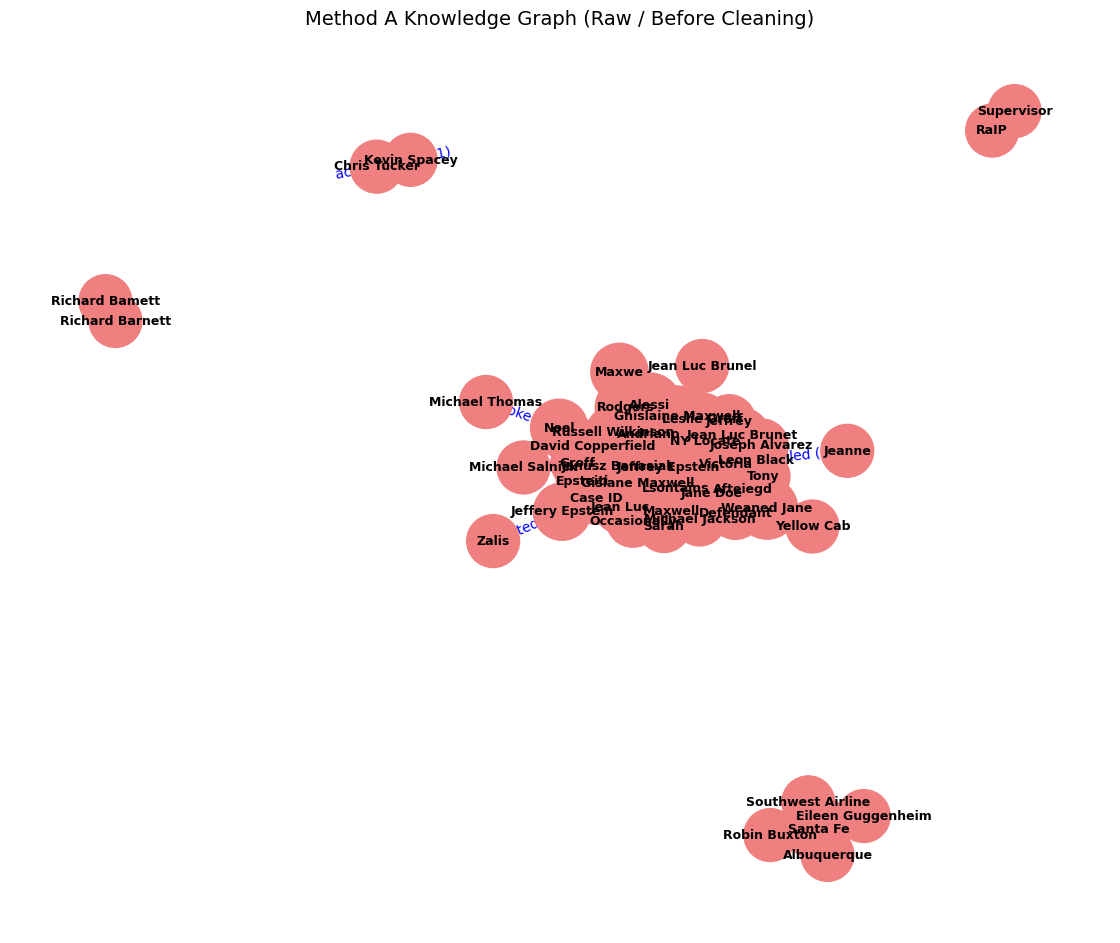

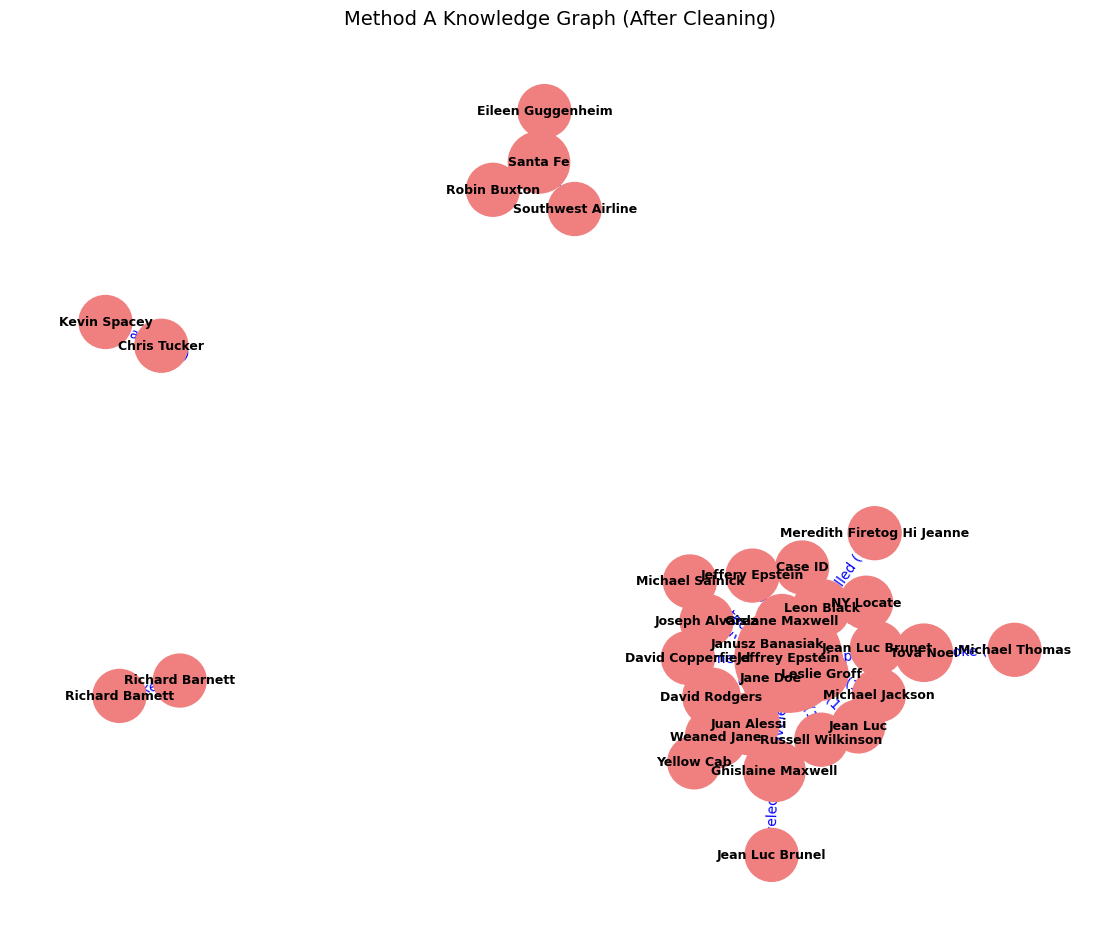

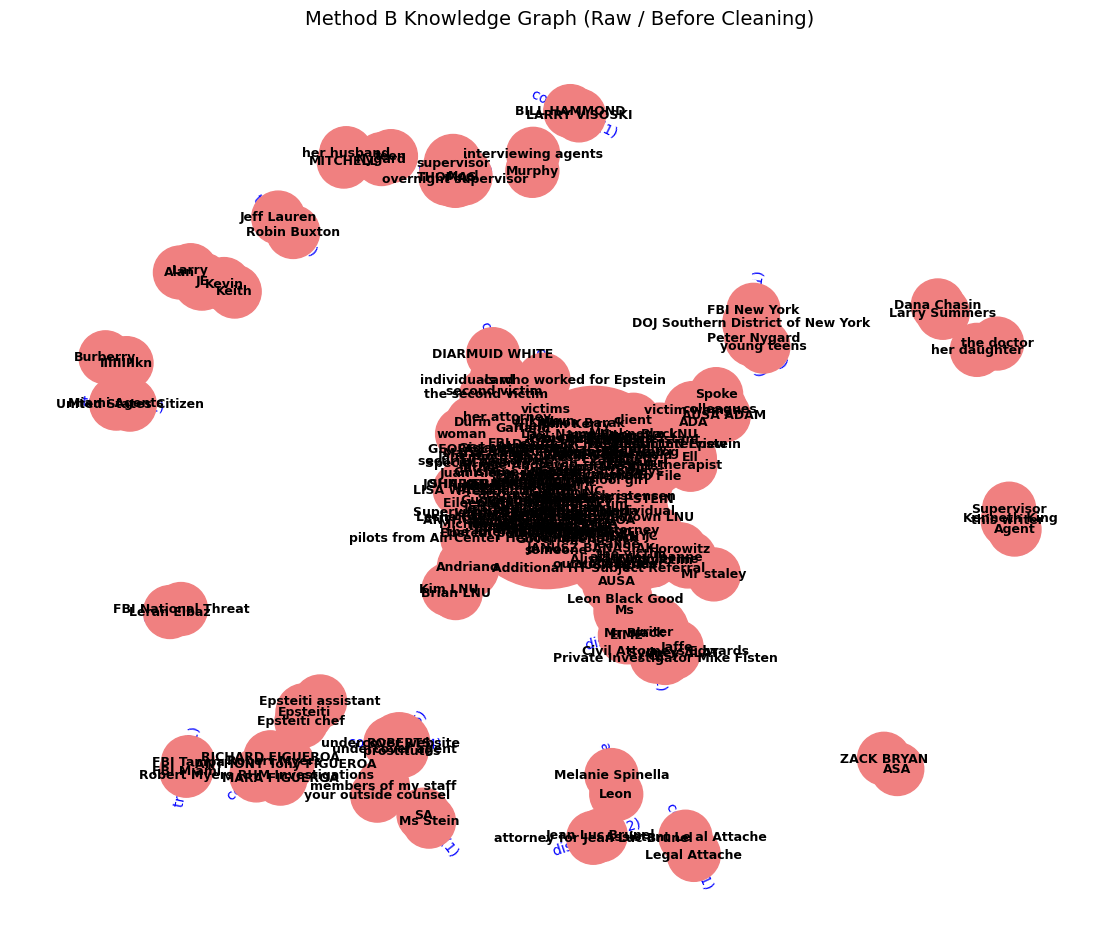

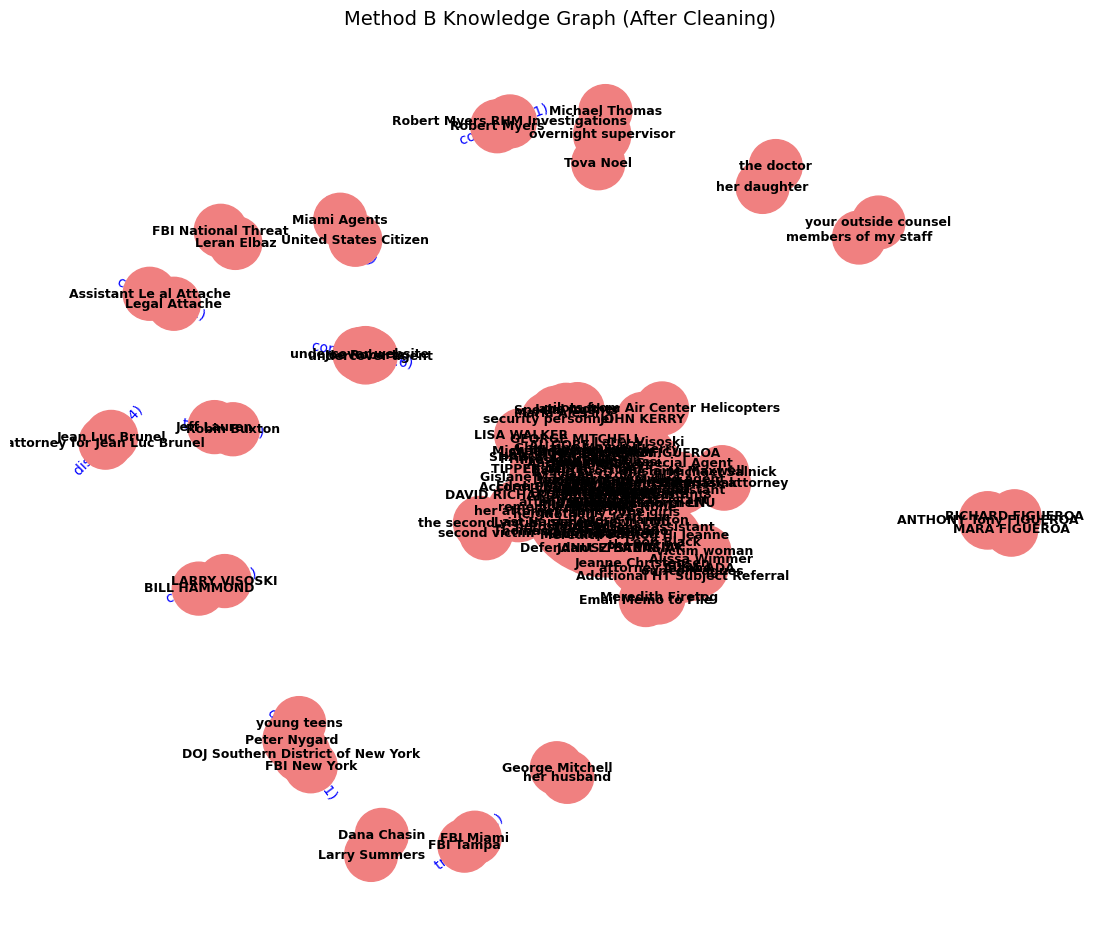

In [86]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

relation_columns = ['Entity1', 'Entity2', 'Interaction', 'Date', 'Location', 'Method', 'Context']

def ensure_graph_df(df_relations):
    if df_relations is None or not isinstance(df_relations, pd.DataFrame) or df_relations.empty:
        return pd.DataFrame(columns=relation_columns + ['Mentions'])

    out = df_relations.copy()
    for col in relation_columns:
        if col not in out.columns:
            out[col] = ''

    if 'Mentions' not in out.columns:
        out['Mentions'] = 1
    else:
        out['Mentions'] = pd.to_numeric(out['Mentions'], errors='coerce').fillna(1)

    return out

def build_edge_summary(df_relations):
    df_plot = ensure_graph_df(df_relations)
    if df_plot.empty:
        return df_plot
    return (
        df_plot.groupby(['Entity1', 'Entity2', 'Interaction'], as_index=False)['Mentions']
        .sum()
        .rename(columns={'Mentions': 'Weight'})
    )

def draw_knowledge_graph(df_relations, title, seed=42):
    edge_summary = build_edge_summary(df_relations)
    if edge_summary.empty:
        print(f'{title}: no relations were found to plot.')
        return

    graph = nx.Graph()
    for _, row in edge_summary.iterrows():
        label = f"{row['Interaction']} ({int(row['Weight'])})"
        graph.add_edge(row['Entity1'], row['Entity2'], label=label, weight=float(row['Weight']))

    plt.figure(figsize=(11, 9))
    pos = nx.spring_layout(graph, seed=seed)

    node_sizes = [1200 + 250 * graph.degree(node) for node in graph.nodes()]
    edge_widths = [1 + graph[u][v]['weight'] * 0.4 for u, v in graph.edges()]

    nx.draw(
        graph,
        pos,
        with_labels=True,
        node_color='lightcoral',
        node_size=node_sizes,
        font_size=9,
        font_weight='bold',
        edge_color='gray',
        width=edge_widths,
    )

    edge_labels = nx.get_edge_attributes(graph, 'label')
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_color='blue')

    plt.title(title, fontsize=14)
    plt.show()

a_raw = globals().get('df_rel_raw_a', globals().get('df_rel_before_clean', pd.DataFrame()))
a_clean = globals().get('df_rel_clean_a', globals().get('df_rel', pd.DataFrame()))
b_raw = globals().get('df_rel_raw_b', globals().get('df_rel_llm_before_clean', pd.DataFrame()))
b_clean = globals().get('df_rel_clean_b', globals().get('df_rel_llm', pd.DataFrame()))

draw_knowledge_graph(
    a_raw,
    title='Method A Knowledge Graph (Raw / Before Cleaning)',
    seed=41,
)

draw_knowledge_graph(
    a_clean,
    title='Method A Knowledge Graph (After Cleaning)',
    seed=42,
)

draw_knowledge_graph(
    b_raw,
    title='Method B Knowledge Graph (Raw / Before Cleaning)',
    seed=98,
)

draw_knowledge_graph(
    b_clean,
    title='Method B Knowledge Graph (After Cleaning)',
    seed=99,
)

In [87]:
from pathlib import Path
import pandas as pd

output_dir = Path('outputs')
output_dir.mkdir(parents=True, exist_ok=True)

def pick_final_df(*names):
    for name in names:
        value = globals().get(name)
        if isinstance(value, pd.DataFrame):
            return value.copy()
    return pd.DataFrame()

df_method_a_final = pick_final_df('df_rel_clean_a', 'df_rel')
df_method_b_final = pick_final_df('df_rel_clean_b', 'df_rel_llm')

method_a_json_path = output_dir / 'method_a_final_relations.json'
method_b_json_path = output_dir / 'method_b_final_relations.json'

df_method_a_final.to_json(method_a_json_path, orient='records', indent=2)
df_method_b_final.to_json(method_b_json_path, orient='records', indent=2)

print(f"Saved Method A final dataframe ({len(df_method_a_final)} rows): {method_a_json_path}")
print(f"Saved Method B final dataframe ({len(df_method_b_final)} rows): {method_b_json_path}")

Saved Method A final dataframe (75 rows): outputs\method_a_final_relations.json
Saved Method B final dataframe (498 rows): outputs\method_b_final_relations.json


In [89]:
from pathlib import Path
from datetime import datetime, timezone
import json
import pandas as pd
import networkx as nx

output_dir = Path('outputs')
output_dir.mkdir(parents=True, exist_ok=True)

RELATION_COLUMNS = [
    'Entity1', 'Entity2', 'Interaction', 'Date', 'Location', 'Method', 'Context', 'SourceFile'
]

def _coerce_relation_df(df):
    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(columns=RELATION_COLUMNS)

    out = df.copy()
    required_cols = RELATION_COLUMNS + ['Mentions']
    for col in required_cols:
        if col not in out.columns:
            out[col] = '' if col != 'Mentions' else 1

    out['Entity1'] = out['Entity1'].astype(str).str.strip()
    out['Entity2'] = out['Entity2'].astype(str).str.strip()
    out['Interaction'] = out['Interaction'].astype(str).str.strip().replace('', 'unknown')
    out['SourceFile'] = out['SourceFile'].astype(str).str.strip()
    out['Mentions'] = pd.to_numeric(out['Mentions'], errors='coerce').fillna(1).clip(lower=1)

    out = out[(out['Entity1'] != '') & (out['Entity2'] != '')].reset_index(drop=True)
    return out

def _pick_df(names, fallback_json_filename):
    for name in names:
        value = globals().get(name)
        if isinstance(value, pd.DataFrame):
            return _coerce_relation_df(value)

    fallback_path = output_dir / fallback_json_filename
    if fallback_path.exists():
        return _coerce_relation_df(pd.read_json(fallback_path))

    return _coerce_relation_df(pd.DataFrame(columns=RELATION_COLUMNS))

def _with_pair_columns(df):
    out = df.copy()
    out['NodeA'] = out[['Entity1', 'Entity2']].min(axis=1)
    out['NodeB'] = out[['Entity1', 'Entity2']].max(axis=1)
    out['PairKey'] = out['NodeA'] + ' || ' + out['NodeB']
    out['PairInteractionKey'] = out['PairKey'] + ' || ' + out['Interaction']
    return out

def _graph_stats(df_pairs):
    graph = nx.Graph()
    if not df_pairs.empty:
        entities = pd.unique(pd.concat([df_pairs['Entity1'], df_pairs['Entity2']], ignore_index=True))
        graph.add_nodes_from(entities.tolist())

        edge_df = df_pairs.groupby(['NodeA', 'NodeB'], as_index=False)['Mentions'].sum()
        for _, row in edge_df.iterrows():
            graph.add_edge(row['NodeA'], row['NodeB'], weight=float(row['Mentions']))

    node_count = graph.number_of_nodes()
    edge_count = graph.number_of_edges()
    density = float(nx.density(graph)) if node_count > 1 else 0.0
    components = list(nx.connected_components(graph)) if node_count > 0 else []
    largest_component_size = max((len(c) for c in components), default=0)
    isolate_count = len(list(nx.isolates(graph))) if node_count > 0 else 0

    return {
        'nodes': int(node_count),
        'edges': int(edge_count),
        'density': round(density, 6),
        'connected_components': int(len(components)),
        'largest_component_size': int(largest_component_size),
        'isolates': int(isolate_count),
    }

def _method_stats(df, total_pdf_files):
    df_pairs = _with_pair_columns(df)

    unique_pairs = int(df_pairs['PairKey'].nunique())
    unique_entities = int(
        pd.unique(pd.concat([df_pairs['Entity1'], df_pairs['Entity2']], ignore_index=True)).size
    )
    unique_source_files = int(df_pairs['SourceFile'].replace('', pd.NA).dropna().nunique())
    source_file_coverage = round(unique_source_files / total_pdf_files, 6) if total_pdf_files else None

    interaction_counts = {
        k: int(v) for k, v in df_pairs['Interaction'].value_counts().head(10).items()
    }

    singleton_rows = int((df_pairs['Mentions'] <= 1).sum())
    evidence_stats = {
        'avg_mentions_per_row': round(float(df_pairs['Mentions'].mean()), 6) if len(df_pairs) else 0.0,
        'median_mentions_per_row': round(float(df_pairs['Mentions'].median()), 6) if len(df_pairs) else 0.0,
        'singleton_rows': singleton_rows,
        'singleton_rate': round(singleton_rows / len(df_pairs), 6) if len(df_pairs) else 0.0,
    }

    stats = {
        'rows': int(len(df_pairs)),
        'unique_pairs': unique_pairs,
        'unique_entities': unique_entities,
        'unique_source_files': unique_source_files,
        'source_file_coverage': source_file_coverage,
        'top_interactions': interaction_counts,
        'evidence': evidence_stats,
        'graph': _graph_stats(df_pairs),
    }
    return stats, df_pairs

total_pdf_files = len(globals().get('pdf_records', [])) if isinstance(globals().get('pdf_records', None), list) else 0

df_method_a = _pick_df(
    names=['df_rel_clean_a', 'df_method_a_final', 'df_rel'],
    fallback_json_filename='method_a_final_relations.json',
)
df_method_b = _pick_df(
    names=['df_rel_clean_b', 'df_method_b_final', 'df_rel_llm'],
    fallback_json_filename='method_b_final_relations.json',
)

method_a_stats, df_method_a_pairs = _method_stats(df_method_a, total_pdf_files)
method_b_stats, df_method_b_pairs = _method_stats(df_method_b, total_pdf_files)

pair_set_a = set(df_method_a_pairs['PairKey'].unique().tolist())
pair_set_b = set(df_method_b_pairs['PairKey'].unique().tolist())
pair_intersection = pair_set_a & pair_set_b
pair_union = pair_set_a | pair_set_b

pair_interaction_set_a = set(df_method_a_pairs['PairInteractionKey'].unique().tolist())
pair_interaction_set_b = set(df_method_b_pairs['PairInteractionKey'].unique().tolist())
pair_interaction_intersection = pair_interaction_set_a & pair_interaction_set_b
pair_interaction_union = pair_interaction_set_a | pair_interaction_set_b

comparison_stats = {
    'pair_overlap_count': int(len(pair_intersection)),
    'pair_overlap_jaccard': round(len(pair_intersection) / len(pair_union), 6) if pair_union else 0.0,
    'pair_interaction_overlap_count': int(len(pair_interaction_intersection)),
    'pair_interaction_overlap_jaccard': round(len(pair_interaction_intersection) / len(pair_interaction_union), 6) if pair_interaction_union else 0.0,
}

report_stats = {
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    'total_pdf_files_loaded': int(total_pdf_files),
    'method_a': method_a_stats,
    'method_b': method_b_stats,
    'comparison': comparison_stats,
}

report_stats_path = output_dir / 'report_stats.json'
with report_stats_path.open('w', encoding='utf-8') as f:
    json.dump(report_stats, f, indent=2)

print(f"Saved report stats JSON: {report_stats_path}")
print(f"Method A rows: {method_a_stats['rows']} | Method B rows: {method_b_stats['rows']}")
print(f"Pair overlap count: {comparison_stats['pair_overlap_count']}")

display(pd.DataFrame([
    {
        'Method': 'A',
        'Rows': method_a_stats['rows'],
        'UniquePairs': method_a_stats['unique_pairs'],
        'UniqueEntities': method_a_stats['unique_entities'],
        'UniqueSourceFiles': method_a_stats['unique_source_files'],
    },
    {
        'Method': 'B',
        'Rows': method_b_stats['rows'],
        'UniquePairs': method_b_stats['unique_pairs'],
        'UniqueEntities': method_b_stats['unique_entities'],
        'UniqueSourceFiles': method_b_stats['unique_source_files'],
    },
]))

Saved report stats JSON: outputs\report_stats.json
Method A rows: 75 | Method B rows: 498
Pair overlap count: 11


,Method,Rows,UniquePairs,UniqueEntities,UniqueSourceFiles
0,A,75,32,33,14
1,B,498,132,129,42
